# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** Darío Martín Romero Cruz

* **matrícula:** A01841015

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Es un problema para predecir si un empleado permanece o no en la empresa. La salida de un empleado puede deberse a temas voluntarios (renuncia) o involuntarios (despido o jubilación). Este es un tema de suma importancia para las organizaciones ya que la contratación y capacitación de nuevo personal suele ser muy costoso no solo en temas monetarios: puede haber pérdida de conocimiento, disminución de la productividad y problemas en el ambiente con el resto del equipo.

Para un ejercicio de aprendizaje automático, se espera que el algoritmo logre predecir si los empleados dejarán la empresa con base a los datos del trabajador. 


++++++++ Termina la sección de agregar texto. +++++++++++

In [14]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [15]:
path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**




Columnas numéricas: 26
Columnas categóricas: 9
Registros duplicados: 0

Nulos por columna:
  > Age: 0.0%
  > Attrition: 0.0%
  > BusinessTravel: 0.0%
  > DailyRate: 0.0%
  > Department: 0.0%
  > DistanceFromHome: 0.0%
  > Education: 0.0%
  > EducationField: 0.0%
  > EmployeeCount: 0.0%
  > EmployeeNumber: 0.0%
  > EnvironmentSatisfaction: 0.0%
  > Gender: 0.0%
  > HourlyRate: 0.0%
  > JobInvolvement: 0.0%
  > JobLevel: 0.0%
  > JobRole: 0.0%
  > JobSatisfaction: 0.0%
  > MaritalStatus: 0.0%
  > MonthlyIncome: 0.0%
  > MonthlyRate: 0.0%
  > NumCompaniesWorked: 0.0%
  > Over18: 0.0%
  > OverTime: 0.0%
  > PercentSalaryHike: 0.0%
  > PerformanceRating: 0.0%
  > RelationshipSatisfaction: 0.0%
  > StandardHours: 0.0%
  > StockOptionLevel: 0.0%
  > TotalWorkingYears: 0.0%
  > TrainingTimesLastYear: 0.0%
  > WorkLifeBalance: 0.0%
  > YearsAtCompany: 0.0%
  > YearsInCurrentRole: 0.0%
  > YearsSinceLastPromotion: 0.0%
  > YearsWithCurrManager: 0.0%




ANALISIS DE LAS VARIABLES NUMERICAS:

Estadistica descriptiva

                           count      mean      std     min       5%      50%  \
Age                       1470.0     36.92     9.14    18.0    24.00     36.0   
DailyRate                 1470.0    802.49   403.51   102.0   165.35    802.0   
DistanceFromHome          1470.0      9.19     8.11     1.0     1.00      7.0   
Education                 1470.0      2.91     1.02     1.0     1.00      3.0   
EmployeeCount             1470.0      1.00     0.00     1.0     1.00      1.0   
EmployeeNumber            1470.0   1024.87   602.02     1.0    96.45   1020.5   
EnvironmentSatisfaction   1470.0      2.72     1.09     1.0     1.00      3.0   
HourlyRate                1470.0     65.89    20.33    30.0    33.00     66.0   
JobInvolvement            1470.0      2.73     0.71     1.0     1.00      3.0   
JobLevel                  1470.0      2.06     1.11     1.0     1.00      2.0   
JobSatisfaction           1470.0      2.73  

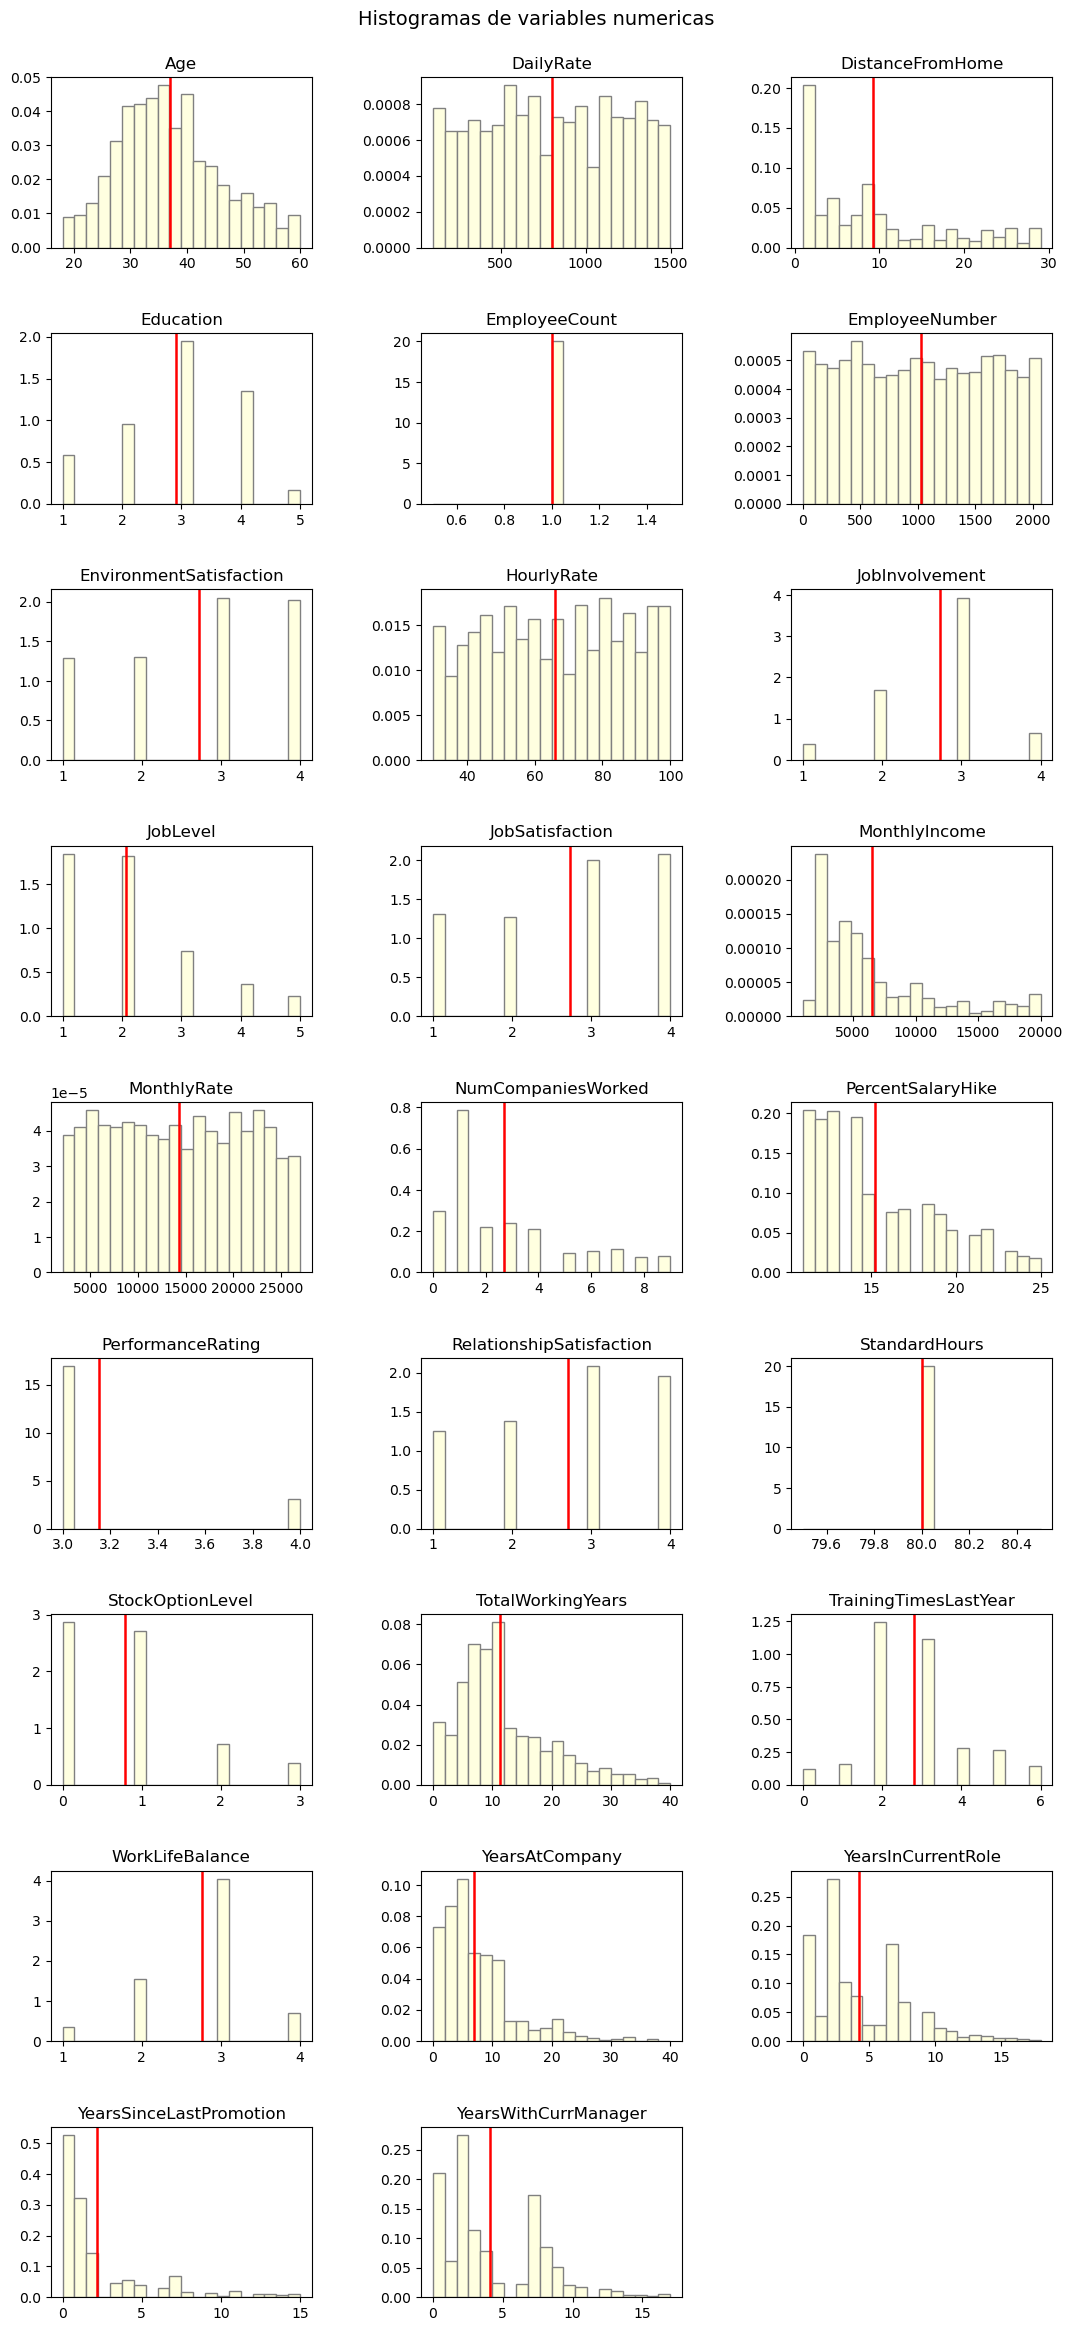



ANALISIS DE LAS VARIABLES CATEGORICAS:

Estadistica descriptiva

               count unique                     top  freq
Attrition       1470      2                      No  1233
BusinessTravel  1470      3           Travel_Rarely  1043
Department      1470      3  Research & Development   961
EducationField  1470      6           Life Sciences   606
Gender          1470      2                    Male   882
JobRole         1470      9         Sales Executive   326
MaritalStatus   1470      3                 Married   673
Over18          1470      1                       Y  1470
OverTime        1470      2                      No  1054

Variables con solo 1 elemento: 
  > Over18


Tablas de frecuencia

  > Attrition
     No: 1233
     Yes: 237

  > BusinessTravel
     Travel_Rarely: 1043
     Travel_Frequently: 277
     Non-Travel: 150

  > Department
     Research & Development: 961
     Sales: 446
     Human Resources: 63

  > EducationField
     Life Sciences: 606
     Medical: 4

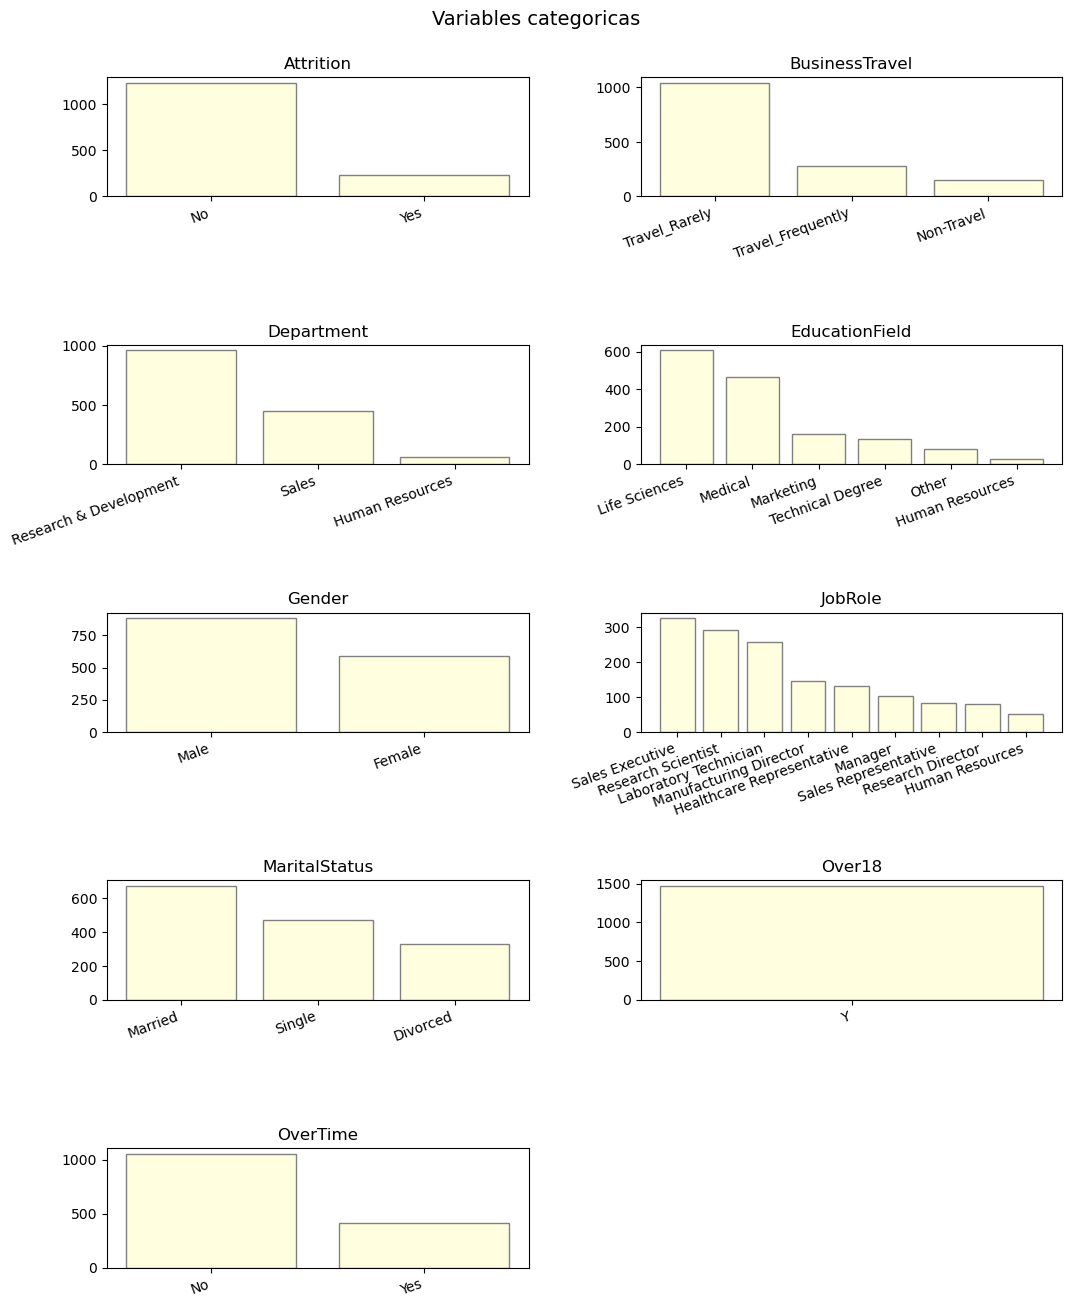

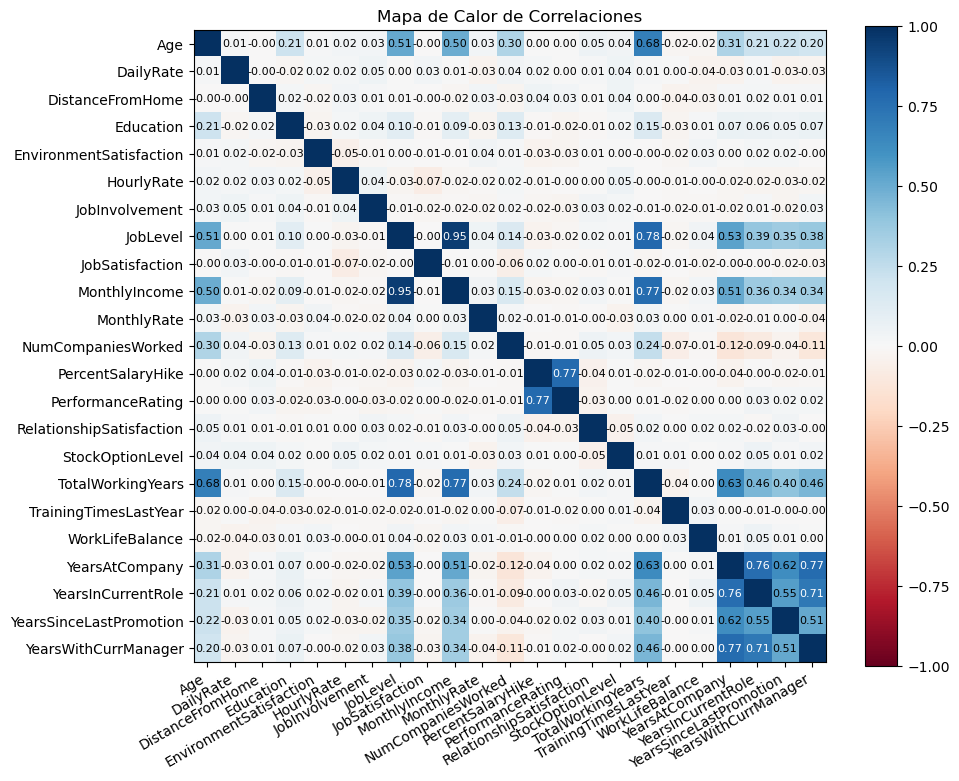


Parejas de variables con alta correlacion:
  > MonthlyIncome - JobLevel: 0.9503


In [16]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

#Columnas numericas y categoricas
num_cols = list(data.select_dtypes(include = np.number).columns)
cat_cols = list(data.select_dtypes(exclude = np.number).columns)

print(f'\nColumnas numéricas: {len(num_cols)}')
print(f'Columnas categóricas: {len(cat_cols)}')

#Revisar duplicados y nulos
print('Registros duplicados:', data.duplicated().sum())

print('\nNulos por columna:')
for col, pct in data.isna().mean().items():
    print(f'  > {col}: {pct:.1%}')


#Obtener estadísticas de las columnas numericas-------------
Stat1 = data[num_cols].describe(percentiles = [0.05, 0.95])
Stat1 = pd.concat([Stat1, data[num_cols].agg(['skew', 'kurt'])]).T #Agregar sesgo y curtosis

#Imprimir resultados
print('\n\nANALISIS DE LAS VARIABLES NUMERICAS:\n\nEstadistica descriptiva\n')
print(Stat1.round(2))
print('\nVariables con desviacion 0: ')
[print('  > ' + v) for v in list(Stat1.loc[Stat1['std'] == 0].index)]

#Histogramas-------------
print('\nHistogramas:')
Fig1 = plt.figure(figsize = (12, 25))
i = 0

for col in num_cols:
    i += 1
    Ax = Fig1.add_subplot(9, 3, i)

    #Histograma
    x = data[col]
    Ax.hist(x, bins = 20, density = True, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.axvline(Stat1.T.loc['mean', col], color = 'red', ls = '-', lw = 1.8, label = 'Media') #Media
    Ax.set_title(col)

Fig1.suptitle('Histogramas de variables numericas', fontsize = 14)    
Fig1.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()


#Obtener estadísticas de las columnas categoricas-------------
data[cat_cols] = data[cat_cols].astype('category') #Pasa columnas tipo object a categoricas
Stat2 = data[cat_cols].describe().T

#Imprimir resultados
print('\n\nANALISIS DE LAS VARIABLES CATEGORICAS:\n\nEstadistica descriptiva\n')
print(Stat2.round(2))
print('\nVariables con solo 1 elemento: ')
[print('  > ' + v) for v in list(Stat2.loc[Stat2['unique'] == 1].index)]



#Tablas de frecuencia-------------
print('\n\nTablas de frecuencia')
for col in cat_cols:
    print(f'\n  > {col}')
    for val, count in data[col].value_counts(dropna = False).items():
        print(f'     {val}: {count}')


#Graficas de barra-------------
Fig2 = plt.figure(figsize = (12, 14))
i = 0

cat_long = []
for Col in cat_cols:
    i += 1
    Ax = Fig2.add_subplot(5, 2, i)

    #Grafico de barras
    Counts = data[Col].value_counts()
    if len(Counts) > 15:
        Counts = Counts.head(15)
        cat_long += [Col]
    #Counts.sort_index(inplace = True)

    Ax.bar(Counts.index.astype(str), Counts.values, color = 'lightyellow', edgecolor = 'gray') # Histograma normalizado
    Ax.set_title(Col)

    #if len(Counts) > 8:
    Ax.tick_params(axis = 'x', rotation = 20)
    for label in Ax.get_xticklabels():
        label.set_ha('right')

Fig2.suptitle('Variables categoricas', fontsize = 14) 
Fig2.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()


num_cols.remove("EmployeeCount")
num_cols.remove("StandardHours")
num_cols.remove("EmployeeNumber")
cat_cols.remove("Over18")



#Tomar solo columnas numericas y aplicar correlación de Pearson
Corr = data[num_cols].corr(method = 'pearson')
nCorr = len(Corr.columns)

#Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

#Dibujar mapa de calor
im = ax.imshow(Corr, vmin = -1, vmax = 1, cmap = 'RdBu')

#Etiquetas
ax.set_xticks(range(nCorr))
ax.set_yticks(range(nCorr))

ax.set_xticklabels(Corr.columns, rotation = 30, ha = 'right')
ax.set_yticklabels(Corr.columns)

#Agregar valores
for i in range(nCorr):
    for j in range(nCorr):
        if i != j:
            TxtColor = 'white' if abs(Corr.iloc[i,j]) > 0.7 else 'black'
            ax.text(j, i, f'{Corr.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 8, color = TxtColor)

# Barra de colores
fig.colorbar(im)
ax.set_title('Mapa de Calor de Correlaciones')

fig.tight_layout()
plt.show()

print('\nParejas de variables con alta correlacion:')
for i in range(nCorr):
    for j in range(i):
        if Corr.iloc[i, j] > 0.9:
            print(f'  > {Corr.index[i]} - {Corr.columns[j]}: {Corr.iloc[i, j]:,.4f}')

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++
df = data.drop(columns = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']).copy()

# Verifiquemos de qué tamaño queda el nuevo DataFrame:
#print("Tamaño del nuevo DataFrame:", df.shape)

**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Se eliminaron las siguientes variables:
* **EmployeeCount**. Al tener todos los datos el mismo valor.
* **StandardHours**. Al tener todos los datos el mismo valor.
* **Over18**. Al tener todos los datos el mismo valor.
* **EmployeeNumber**. Por no ser relevante en el contexto, es un identificador. Evidentemente, su distribución será uniforme.

Si fuera a eliminar otra variable, podría ser **JobLevel** al estar fuertemente correlacionada con **MonthlyIncome**.

++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

**Indpendientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


++++++++ Inicia la sección de agregar texto: ++++++++++++


Si se ocupan dichos datos (edad, genero o estado civil) para realizar decisiones que involucren las condiciones de los empleados, se podría caer en temas de discriminación. Esto podría conllevar a una demanda importante a la empresa. Incluso, si no tomaramos en cuenta estas variables, también se podríamos incurrir en cierta "discriminación indirecta" al usar variables fuertemente correlacionadas a ellas, como puede ser `TotalWorkingYears` con `Age` (correlación de 0.68). También puede ser problema el uso de datos sensibles sin la aprobación del empleado. Finalmente, podríamos provocar cierto sesgo si nuestro modelo predice que una persona va a renunciar y por lo tanto se le niegan ciertos beneficios, llevando a la persona en cuestión a renunciar.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

Podría ser un problema de optimización, o para ver que tipos de beneficios pueden ser más relevantes para mantener al talento y distribuir un presupuesto limitado hacia estos.
Otro enfoque sería de clustering, para encontrar perfiles de empleados similares que requieran atención parecida. Por ejemplo, una capacitación técnica o algún tipo especial de seguro.


++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [17]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [18]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

le = LabelEncoder()
ytrainT = pd.DataFrame(le.fit_transform(np.ravel(ytrain)), columns=['Attrition'], index=ytrain.index)  # fit SOLO en train
yvalT   = pd.DataFrame(le.transform(np.ravel(yval)),  columns=['Attrition'], index=yval.index)
ytestT  = pd.DataFrame(le.transform(np.ravel(ytest)), columns=['Attrition'], index=ytest.index)
print('Clases:', le.classes_)   # No = 0, Yes = 1

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Clases: ['No' 'Yes']
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**



++++++++ Inicia la sección de agregar texto: ++++++++++++

b) Según la documentación de Sklearn, `LabelEncoder` se le debe aplicar a la variable objetivo (`y`), no a las variables de entrada `X`.  

c) `Attrition = 0` significa que el empleado sigue en la empresa. `Attrition = 1` indica que la abandonó.

d) El modelo ingenuo no mira ninguna variable y siempre responde lo mismo: la clase más frecuente. La cual, para este problema, usando solo los datos de entrenamiento, es el 'No' con un 83.87%. Este sería el umbral a superar; un modelo con `accuracy <= 0.8387` está subentrenado.

e) Si, aunque es un desbalanceo moderado: La proporción es de 84/16 (aproximadamente 5/1). Métricas que podrían ser más adecuadas en esta situación serían: recall (sensibilidad) de la clase 'Yes', precisión, F1-score o la matriz de confusión.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


Sesgo de numéricas (train):
 HourlyRate                -0.07
DailyRate                 -0.02
MonthlyRate                0.04
Age                        0.43
TrainingTimesLastYear      0.51
YearsWithCurrManager       0.75
PercentSalaryHike          0.84
YearsInCurrentRole         0.87
DistanceFromHome           0.89
NumCompaniesWorked         1.08
TotalWorkingYears          1.16
MonthlyIncome              1.39
YearsAtCompany             1.81
YearsSinceLastPromotion    2.04
dtype: float64



Education
 Attrition     No    Yes
Education              
1          0.782  0.218
2          0.847  0.153
3          0.839  0.161
4          0.851  0.149
5          0.879  0.121

EnvironmentSatisfaction
 Attrition                   No    Yes
EnvironmentSatisfaction              
1                        0.741  0.259
2                        0.848  0.152
3                        0.867  0.133
4                        0.865  0.135

JobInvolvement
 Attrition          No    Yes
JobInvolvement              
1               0.625  0.375
2               0.803  0.197
3               0.862  0.138
4               0.903  0.097

JobLevel
 Attrition     No    Yes
JobLevel               
1          0.743  0.257
2          0.895  0.105
3          0.861  0.139
4          0.923  0.077
5          0.943  0.057

JobSatisfaction
 Attrition           No    Yes
JobSatisfaction              
1                0.757  0.243
2                0.837  0.163
3                0.846  0.154
4                0.883  0.11

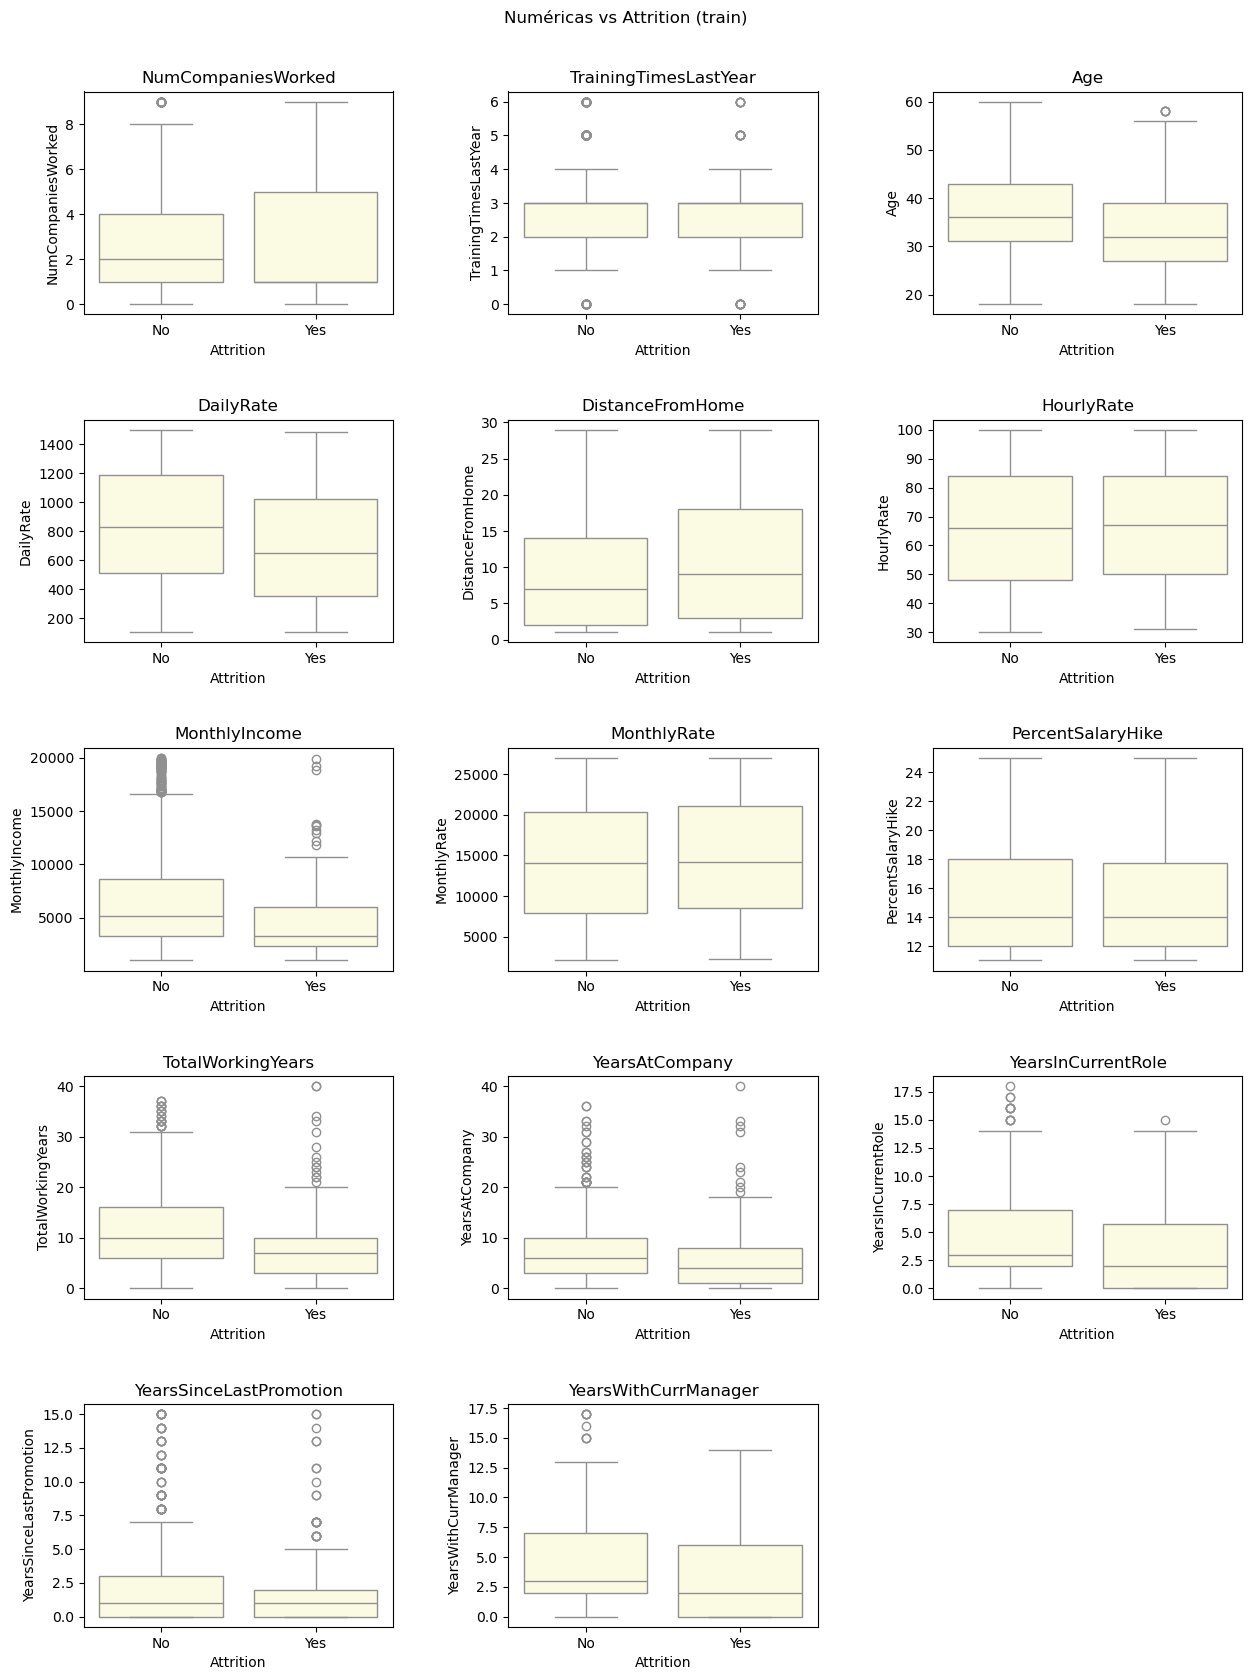

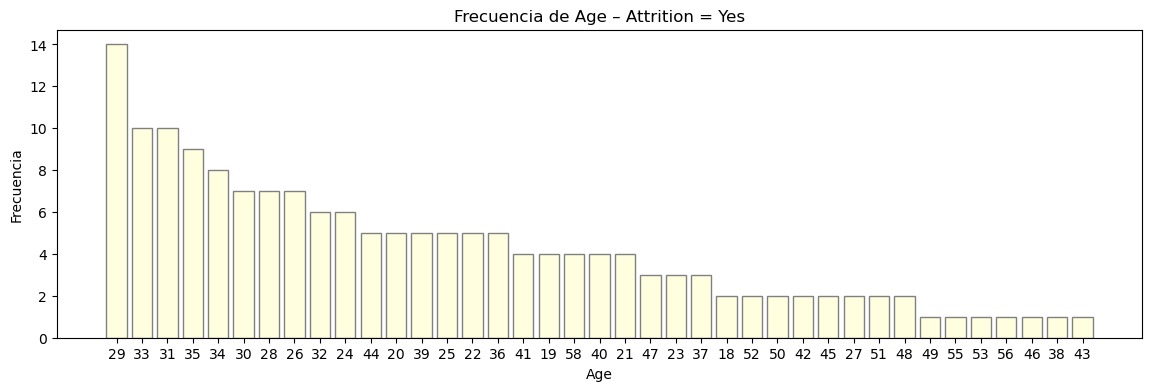

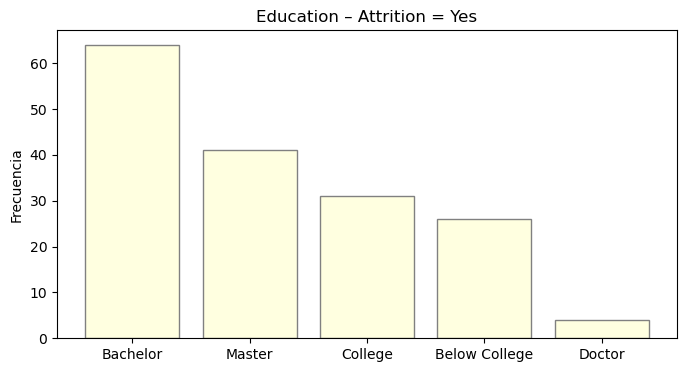

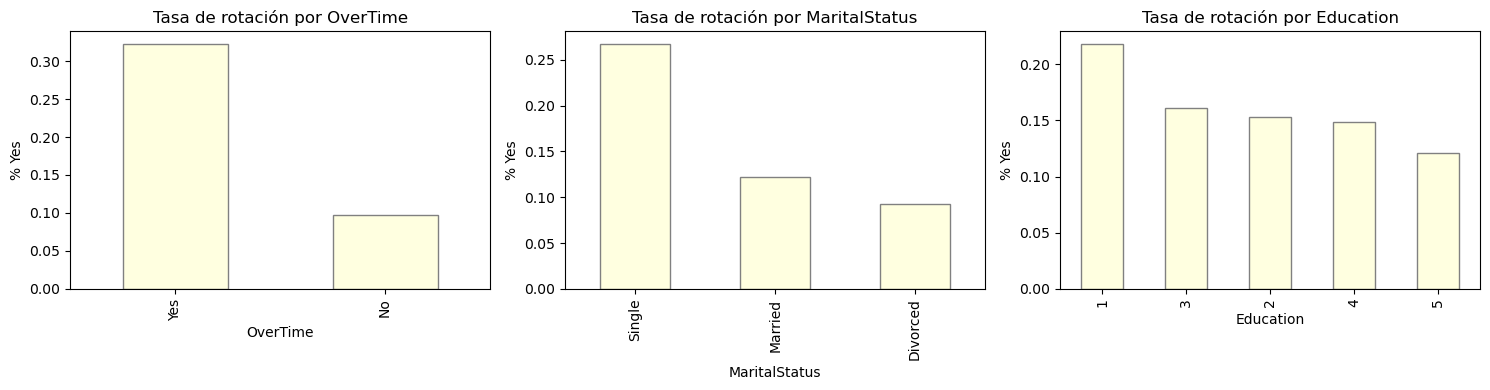

In [19]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

num_vars = ['NumCompaniesWorked','TrainingTimesLastYear','Age','DailyRate','DistanceFromHome','HourlyRate',
            'MonthlyIncome','MonthlyRate','PercentSalaryHike','TotalWorkingYears','YearsAtCompany',
            'YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
ord_vars = ['Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction',
            'PerformanceRating','RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance']
bin_vars = ['Gender','OverTime']
nom_vars = ['BusinessTravel','Department','EducationField','JobRole','MaritalStatus']

train = Xtrain.copy(); train['Attrition'] = ytrain['Attrition']

print('Sesgo de numéricas (train):\n', train[num_vars].skew().sort_values().round(2))

fig, axs = plt.subplots(5, 3, figsize=(14, 18)); axs = axs.ravel()
for i, c in enumerate(num_vars):
    sns.boxplot(data=train, x='Attrition', y=c, ax=axs[i], color='lightyellow'); axs[i].set_title(c)
axs[-1].axis('off'); fig.suptitle('Numéricas vs Attrition (train)')

for c in ord_vars + bin_vars + nom_vars:
    print(f'\n{c}\n', pd.crosstab(train[c], train['Attrition'], normalize='index').round(3))

fig.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.97])
plt.show()

# b) Gráfico age-attrition[yes]

age_yes = train.loc[train['Attrition']=='Yes', 'Age'].value_counts()   # value_counts ya ordena desc
#age_yes.sort_index(inplace = True)
plt.figure(figsize=(14,4))
plt.bar(age_yes.index.astype(str), age_yes.values, color='lightyellow', edgecolor='gray')
plt.title('Frecuencia de Age – Attrition = Yes'); plt.xlabel('Age'); plt.ylabel('Frecuencia'); plt.show()

# c) Gráfico education-attrition[yes]

edu_map = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
edu_yes = train.loc[train['Attrition']=='Yes', 'Education'].map(edu_map).value_counts()
plt.figure(figsize=(8,4))
plt.bar(edu_yes.index, edu_yes.values, color='lightyellow', edgecolor='gray')
plt.title('Education – Attrition = Yes'); plt.ylabel('Frecuencia'); plt.show()

# d) [gráfico opcional]

fig, axs = plt.subplots(1, 3, figsize=(15,4))
for ax, c in zip(axs, ['OverTime','MaritalStatus','Education']):
    (train.groupby(c, observed=True)['Attrition'].apply(lambda s: (s=='Yes').mean())
          .sort_values(ascending=False).plot.bar(ax=ax, color='lightyellow', edgecolor='gray'))
    ax.set_title(f'Tasa de rotación por {c}'); ax.set_ylabel('% Yes')
fig.tight_layout(); plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**Conclusiones de las gráficas 6a - 6d**

* a) Aunque no existen datos faltantes ni duplicados en el dataset, se agregará un `SimpleImputer` para tener un pipeline robusto para nuevos datos. Además:
     * Variables numéricas: Se puede observar sesgo positivo en varias de las variables (`YearsSinceLastPromotion` 2.04, `YearsAtCompany` 1.81, `MonthlyIncome` 1.39), así como algunos outliers en la cola derecha, por ello se aplicará `PowerTransformer` (Yeo-Johnson). Finalmente `MinMaxScaler` para dejar las variables en rangos comparables.
     * Variables ordinales: Solo se usará una transformación de escalamiento `MinMaxScaler`.
     * Binarias y nominales: No tienen orden, así que solo se usará `One-Hot`.

* b) Se observa que la rotación se concentra especialmente en los jóvenes, siendo la edad más frecuente 29 años, seguida de 31 y 33. Así, un 68.7% de los empleados que se fueron tienen 35 años o menos.

* c) Se observa como **Bachelor** es la clase con más casos. Sin embargo, este es el grupo más grande así que el resultado era esperado.

* d) Estas gráficas no consideran los totales sino la tasa de los que se fueron contra el total (% Yes). De este modo, se ve que variables realmente influyentes son la presencia de tiempos extra (OverTime) y el estado civil de los empleados (se van quienes mayormente están solteros). Del nivel de educación, se observa ahora como una menor educación también puede ser un factor de rotación.

**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Para este problema, los más costosos serían los **Falsos Negativos**: no detectar a tiempo a alguien que se irá, lo cual implica reclutamiento, capacitación y pérdida de conocimiento. Un **Falso Positivo** solo implicaría una reunión de prevención con el empleado quizá innecesariamente, pero el costo de esto es relativamente bajo.

++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [20]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline(steps=[('impMediana', SimpleImputer(strategy='median')),
                                     ('yeoJohnson', PowerTransformer(method='yeo-johnson')),
                                     ('escalaNum', MinMaxScaler())])
numericas_pipeline_nombres = num_vars

# ORDINALES:
catOrd_pipeline = Pipeline(steps=[('impModa', SimpleImputer(strategy='most_frequent')),
                                  ('escalaOrd', MinMaxScaler())])
catOrd_pipeline_nombres = ord_vars

# BINARIAS:
catBin_pipeline = Pipeline(steps=[('impModa', SimpleImputer(strategy='most_frequent')),
                                  ('oheBin', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))])
catBin_pipeline_nombres = bin_vars

# NOMINALES:
catNom_pipeline = Pipeline(steps=[('impModa', SimpleImputer(strategy='most_frequent')),
                                  ('oheNom', OneHotEncoder(handle_unknown='ignore'))])
catNom_pipeline_nombres = nom_vars


columnasTransformer = ColumnTransformer(transformers=[
        ('num', numericas_pipeline, numericas_pipeline_nombres),
        ('ord', catOrd_pipeline,    catOrd_pipeline_nombres),
        ('bin', catBin_pipeline,    catBin_pipeline_nombres),
        ('nom', catNom_pipeline,    catNom_pipeline_nombres)],
        remainder='drop')


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

La justificación de estas transformaciones ya se hizo en el ejercicio anterior (6a).

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [21]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.886 (0.014)
>> LASSO 0.886 (0.013)
>> RIDGE 0.888 (0.013)
>> EN 0.888 (0.014)
>> KNN 0.853 (0.009)


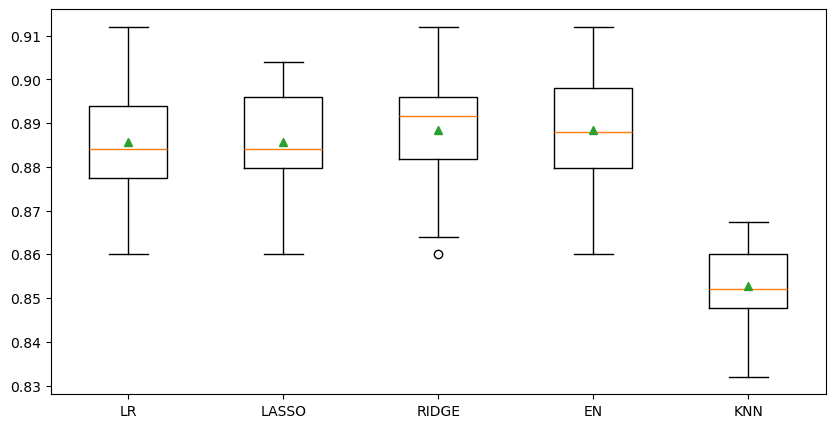

In [22]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(#penalty=None,  # Este valor de "None" no lo debes cambiar. Define al modelo sin regularización.
                                    C=1e10, #penalty está deprecado desde sklearn 1.8, esta linea es equivalente
                                    solver='lbfgs', max_iter=5000,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LR')


  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(#penalty='l1',
                                    l1_ratio=1, #penalty está deprecado desde sklearn 1.8, esta linea es equivalente
                                    C=1.0, solver='liblinear', max_iter=5000,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LASSO')


  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(#penalty='l2',
                                    l1_ratio=0, #penalty está deprecado desde sklearn 1.8, esta linea es equivalente
                                    C=1.0, solver='lbfgs', max_iter=5000,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('RIDGE')


  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(#penalty='elasticnet',
                                    l1_ratio=0.5, #penalty está deprecado desde sklearn 1.8, esta linea es equivalente
                                    C=1.0, solver='saga', max_iter=10000,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('EN')


  # KNN - K-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=15, weights='distance', p=1    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                      ))
  nombres.append('KNN')

  return modelos, nombres


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Los cuatro modelos lineales quedaron con una exactitud entre 88.6 y 88.8%, la cual está por encima del umbral definido por el modelo ingenuo (83.9%). Aún así, los modelos que resultaron ser ligeramente mejores al resto fueron **RIDGE** (Regresión Logística con Regularización L2) y **EN** (Red Elástica). Sin embargo, de elegir uno, se elegiría RIDGE por tener una mediana ligeramente más alta y una desviación estándar ligeramente más baja. Además, es un modelo más simple que EN, ya que necesita menos hiperparámetros.
Por otro lado, el modelo que podríamos considerar subentrenado sería el **kNN**, el cual apenas se encuentra por encima del modelo ingenuo. El problema es que al tener un problema tan desbalanceado, la mayoría de los vecinos casi siempre salen como 'No'.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [23]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

pipe_ridge = Pipeline(steps=[('ct', columnasTransformer),
                             ('m', LogisticRegression(l1_ratio=0, solver='lbfgs', max_iter=5000, random_state=1))])

malla = {'m__C': [0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5]}
cv2 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

resultado_malla = GridSearchCV(pipe_ridge, param_grid=malla, scoring='accuracy',
                               cv=cv2, return_train_score=True, n_jobs=-1).fit(Xtv, np.ravel(ytv))

i = resultado_malla.best_index_
print('Mejor C -> Train: %.2f%% | Val: %.2f%%' % (100*resultado_malla.cv_results_['mean_train_score'][i],
                                                 100*resultado_malla.cv_results_['mean_test_score'][i]))
print('')

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Mejor C -> Train: 90.23% | Val: 88.84%

Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.888441 usando los hiperparámetros {'m__C': 1}
Promedios Train mean(std): 88.45% (0.3836%)
Promedios Val mean(std): 87.44% (1.0763%)


Se observa que con el mejor C (C = 1): Train 90.2% y Val 88.8%, lo cual da una diferencia de 1.4% < 3%, así que no está sobreentrenado.
Además, 88.8% > 83.9%, así que tampoco está subentrenado.

# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [24]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

mejor_modelo = resultado_malla.best_estimator_
ypred = mejor_modelo.predict(Xtest)
print(classification_report(np.ravel(ytestT), ypred, target_names=['No','Yes']))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


              precision    recall  f1-score   support

          No       0.89      0.97      0.93       185
         Yes       0.68      0.36      0.47        36

    accuracy                           0.87       221
   macro avg       0.79      0.66      0.70       221
weighted avg       0.85      0.87      0.85       221



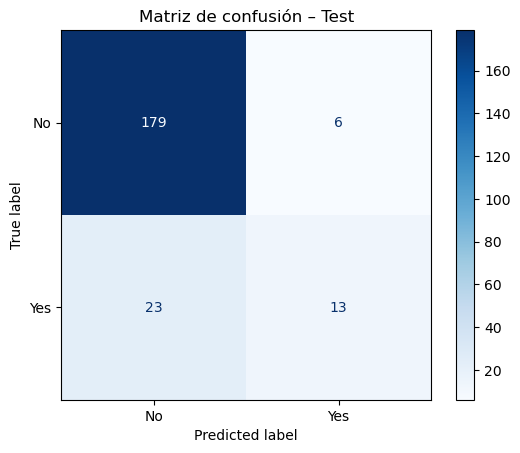

In [25]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

ConfusionMatrixDisplay.from_predictions(np.ravel(ytestT), ypred, display_labels=['No','Yes'], cmap='Blues')
plt.title('Matriz de confusión – Test'); plt.show()

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

* **VP = 13** := Empleados que el modelo predijo que se iban y acertó.

* **VN = 179** := Empleados que el modelo predijo que se quedaban y acertó.

* **FP = 6** := Empleados que el modelo predijo que se iban pero se quedaron.

* **FN = 23** := Empleados que el modelo predijo que se quedaba pero se fueron.

De estos datos, observamos un **recall** de 36%, esto es: de los 36 empleados que se fueron, el modelo solo identificó a 13. La **precisión** fue del 68% y la **exactitud** del 87%.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

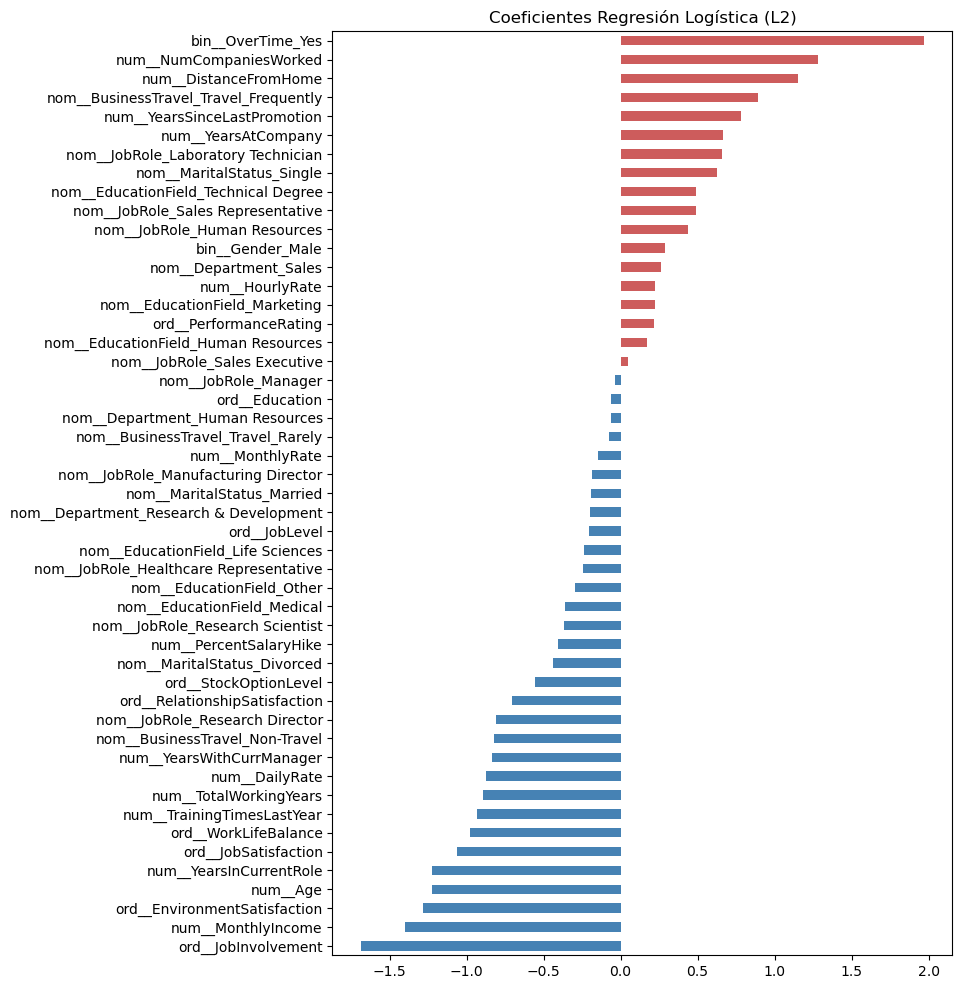

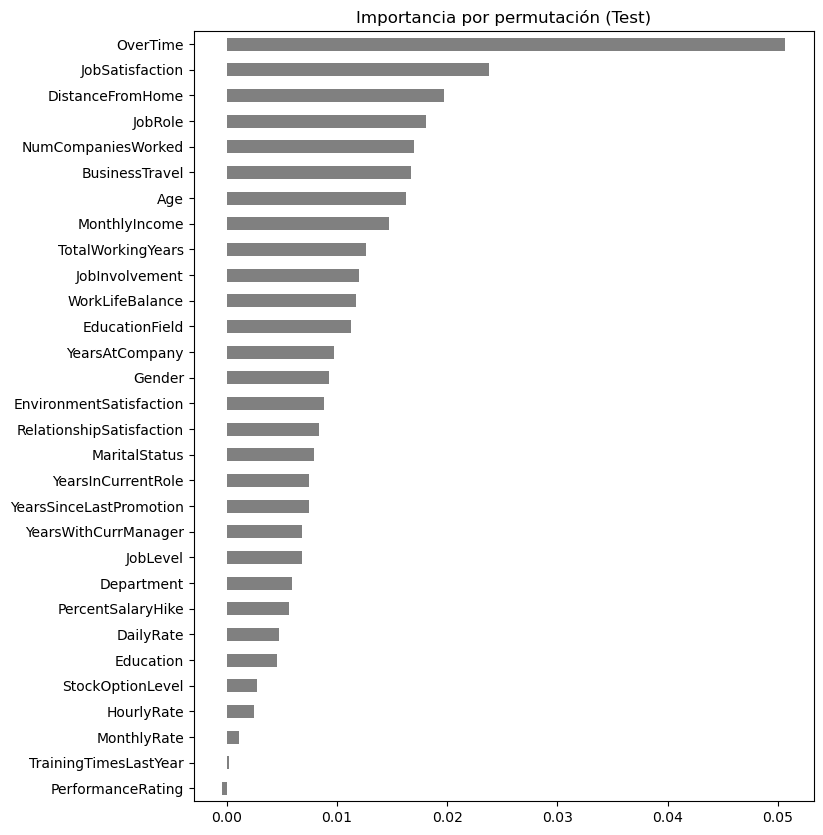

In [26]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

from sklearn.inspection import permutation_importance

nombres_ct = mejor_modelo.named_steps['ct'].get_feature_names_out()
coefs = pd.Series(mejor_modelo.named_steps['m'].coef_[0], index=nombres_ct).sort_values()
plt.figure(figsize=(8,12)); coefs.plot.barh(color=np.where(coefs>0,'indianred','steelblue'))
plt.title('Coeficientes Regresión Logística (L2)'); plt.show()

perm = permutation_importance(mejor_modelo, Xtest, np.ravel(ytestT), scoring='accuracy', n_repeats=20, random_state=1)
imp = pd.Series(perm.importances_mean, index=Xtest.columns).sort_values()
plt.figure(figsize=(8,10)); imp.plot.barh(color='gray'); plt.title('Importancia por permutación (Test)'); plt.show()

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

* Los factores que aumentan el riesgo de renuncia (coeficientes positivos) fueron: OverTime_Yes (1.97), NumCompaniesWorked (1.28), DistanceFromHome (1.15), BusinessTravel_Travel_Frequently (0.89), YearsSinceLastPromotion (0.78), JobRole_Laboratory Technician y MaritalStatus_Single.
* Por otro lado, los que reducen el riesgo (coeficientes negativos) son: JobInvolvement (−1.69), MonthlyIncome (−1.40), EnvironmentSatisfaction (−1.28), Age (−1.22), YearsInCurrentRole, JobSatisfaction y WorkLifeBalance.
* Al aplicar importancia por permutación, este análisis confirmó la importancia de OverTime sobre el resto.
* Casi todos los factores que aumentan el riesgo de renuncia son situaciones que la empresa puede mejorar.

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


* a) La predicción debe usarse para tomar acciones preventivas (revisar incurrencia en horas extra, salarios, planes de carrera, trabajo remoto para quien vive lejos). No debe usarse para castigar ni excluir a nadie (negar promociones o capacitación, despidos anticipados). El acceso a estos datos debe ser restringido, con transparencia hacia los colaboradores sobre qué datos se usan y con qué fin. Las decisiones finales las toma una persona, no el modelo. Y conviene una revisión constante del peso que tiene en el modelo datos sensibles, para evitar el tema de discriminación.

* b) El modelo obtuvo 23 FN vs 6 FP: está siendo "conservador" y considera más costosos los FP. No coincide con mi respuesta del ejercicio 6e, donde se concluyó que los FN son más caros. Para corregirlo habría que optimizar, quizá utilizar otra métrica.

* c) Para directivos: "De cada 10 predicciones, casi 9 son correctas, pero de cada 3 personas que realmente se van, hoy solo identificamos 1. Los principales factores para que alguien deje la compañía son: trabajar horas extra, sueldo bajo, poca satisfacción con el ambiente y el puesto, viajes frecuentes, vivir lejos y años sin ser promovido." Usaría gráficas simples para justificar los puntos anteriores y ligaría mis conclusiones con la parte de costos (cuánto cuesta reemplazar a alguien frente a una acción de retención). Terminaría dando sugerencias directas para evitar estos factores de riesgo.

* d) En mi caso, usando Claude (Anthropic), esta herramienta fue de más ayuda en los ejercicios 7–9: armar el ColumnTransformer, elegir las combinaciones válidas de solver y configurar GridSearchCV con return_train_score. También fue de ayuda para resolver dudas más técnicas sobre la aplicación de las diferentes estrategias. Y para generar ideas de resolución.

* e) Conclusiones: se construyó un pipeline completo sin fuga de información, aplicando la división de datos en las 3 categorías recomendadas: training, validation y test. Durante la comparación de modelos, la regresión logística con L2 (C=1) logró 88.8% en validación y 86.9% en test, superando el modelo ingenuo de 83.9% sin sobreentrenarse. Sin embargo, la exactitud resultó engañosa con clases desbalanceadas: el modelo solo detecta el 36% de las renuncias, no detectando 2 de cada 3 renuncias. El siguiente paso es optimizar métricas como recall o F1, y balancear las clases. Los factores clave (horas extra, salario, satisfacción, involucramiento, viajes, distancia y promociones) son en su mayoría accionables que están en manos de la empresa corregir. También aprendimos que detrás de este tipo de algoritmo, siempre hay un tema de responsabilidad ética y respeto a la privacidad.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<